# Global sensitivity analysis: Mass-action kinetics, double binding 

Nathaniel Linden (UCSD MAE) - March  2023

In [2]:
import numpy as np
from SALib.sample import sobol as sobol_samp
from SALib.sample import morris as morris_samp
from SALib.analyze import sobol as sobol_analyze
from SALib.analyze import morris as morris_analyze
from SALib.analyze.hdmr import analyze as hdmr_analyze
import os
import sys

import jax  
import jax.numpy as jnp
import jax.scipy as jsp
import scipy.optimize as opt
from jax import lax
import equinox as eqx
import diffrax as dfrx

import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from scipy.stats import t
import ipywidgets as widgets

jax.config.update('jax_enable_x64', True)
# load code
# sys.path.insert(0, '/scratch/nlinden/AMPK/src/ampk_models/odes')
# sys.path.insert(0, '/scratch/nlinden/AMPK/src/ampk_models/global_sensitivity_analysis')
sys.path.insert(0, '../odes')
import ampk_MA_double_mech_diffrax as model
import ampk_MA_double_mech as model1
from gsa_utils import *
import gsa_utils

%matplotlib inline
plt.style.use('~/.matplotlib/custom.mplstyle')
mpl.rcParams['figure.autolayout'] = True

### Now load the parameter values and solutions for the sensitivity analysis
We will use the same parameter values as in the previous notebook, but we will use the solutions generated with the diffrax solver.
Additionally, we will use the $\pm 50 \%$ bounds for the sensitivity analysis.

In [3]:
# load samples
param_vals_sobol_corr = np.load('./MA_double_mech_tmp/param_vals_sobol_MA_corr.npy')


# load solutions
sobol_sols_corr = np.load('./MA_double_mech_tmp/sols_sobol_corr.npy')

# reshape into 2D array
sobol_sols_corr = sobol_sols_corr.reshape(sobol_sols_corr.shape[0]*sobol_sols_corr.shape[1], sobol_sols_corr.shape[2])
nsols, nqoi = sobol_sols_corr.shape

In [4]:
ss_pre = [(sol[0], idx) for sol, idx in zip(sobol_sols_corr, range(nsols))]
print('There are', nsols, 'total correlated Sobol samples.')
print(sum([ss[0] < 0.0 for ss in ss_pre]), 'of them have negative initial steady-states')

neg_idxs = []
nans = []
for ss in ss_pre:
    if ss[0] <0.0:
        neg_idxs.append(ss[1])
# param_vals_sobol_corr[neg_idxs]


There are 61440 total correlated Sobol samples.
0 of them have negative initial steady-states


In [5]:
MA_nominals = pd.read_csv('nominal_params_MA_tmp.csv')
MM_nominals = pd.read_csv('nominal_params_MM_tmp.csv')
nominal_vals_MA = MA_nominals['value'].to_list()
param_names_MA = MA_nominals['parameter'].to_list()
nominal_vals_MM = MM_nominals['value'].to_list()
param_names_MM = MM_nominals['parameter'].to_list()

# metabolism_params
metab_parms_basal = {'kGly': 1300.0,'kHydro':1.4e-3,'kForAK':40.44,
                     'kRevAK':1.1e-3,'VmaxOxPhos':0.5,'Kadp': 5.8e-2,'n': 2.568,}
metab_parms_stress = {'kGly': 4.5,'kHydro':1.4e-3,'kForAK':40.44,
                      'kRevAK':1.1e-3,'VmaxOxPhos':0.5,'Kadp': 5.8e-2,'n': 2.568,}

# bounds and problem dicts for SALib
lb_mult = 0.9
ub_mult = 1.9
bounds_MA = [[lb_mult*param, ub_mult*param] for param in nominal_vals_MA]
bounds_MM = [[lb_mult*param, ub_mult*param] for param in nominal_vals_MM]

# update bounds to correlated min/max
to_set = ['kOnCaMKK', 'kOnLKB1','kOnPP','kOnAMPK','kOnPP1']
kon_idxs_MA = [param_names_MA.index(item) for item in to_set]
for idx in kon_idxs_MA:
    bounds_MA[idx][0] = np.min(param_vals_sobol_corr[:,idx])
    bounds_MA[idx][1] = np.max(param_vals_sobol_corr[:,idx])

# dictionary of the problem for SALib
problem = {'num_vars':14, 'names':param_names_MA, 'bounds': bounds_MA,}
bounds_MM = {'num_vars':14, 'names':param_names_MM, 'bounds': bounds_MM,}


# states and initial conditions
state_names = ['AMP', 'ADP', 'ATP', 'AMPK', 'pAMPK', 'AMP_AMPK', 'ADP_AMPK', 'ATP_AMPK', 'AMP_pAMPK', 'ADP_pAMPK', 'ATP_pAMPK', 'AMP_AMP_AMPK', 'AMP_ADP_AMPK', 'AMP_ATP_AMPK', 'ADP_ADP_AMPK', 'ADP_ATP_AMPK', 'ATP_ATP_AMPK', 'AMP_AMP_pAMPK', 'AMP_ADP_pAMPK', 'AMP_ATP_pAMPK', 'ADP_ADP_pAMPK', 'ADP_ATP_pAMPK', 'ATP_ATP_pAMPK', 'CaMKK', 'CaMKK_AMPK', 'CaMKK_AMP_AMPK', 'CaMKK_ADP_AMPK', 'CaMKK_ATP_AMPK', 'CaMKK_AMP_AMP_AMPK', 'CaMKK_AMP_ADP_AMPK', 'CaMKK_AMP_ATP_AMPK', 'CaMKK_ADP_ADP_AMPK', 'CaMKK_ADP_ATP_AMPK', 'CaMKK_ATP_ATP_AMPK', 'LKB1', 'LKB1_AMP_AMPK', 'LKB1_ADP_AMPK', 'LKB1_AMP_AMP_AMPK', 'LKB1_AMP_ADP_AMPK', 'LKB1_ADP_ADP_AMPK', 'PP', 'PP_pAMPK', 'PP_ATP_pAMPK', 'PP_AMP_ATP_pAMPK', 'PP_ADP_ATP_pAMPK', 'PP_ATP_ATP_pAMPK', 'AMPKAR', 'pAMPKAR', 'AMPKAR_AMP_pAMPK', 'AMPKAR_AMP_AMP_pAMPK', 'AMPKAR_AMP_ADP_pAMPK', 'PP1', 'PP1_pAMPKAR']

ampkar_idx = state_names.index('AMPKAR')
pampkar_idx = state_names.index('pAMPKAR')

# Set initial conditions
to_set = ['AMP', 'ADP', 'ATP', 'AMPK', 'CaMKK', 'LKB1', 'PP', 'AMPKAR', 'PP1']
idxs = [state_names.index(item) for item in to_set]
y0 = np.zeros((53,))
y0[idxs[0]] = 2e-5   # AMP
y0[idxs[1]] = 1.3e-1 # ADP
y0[idxs[2]] = 8.2   # ATP
y0[idxs[3]] = 0.6   # AMPK
y0[idxs[4]] = 1.0   # CaMKK
y0[idxs[5]] = 1.0   # LKB1
y0[idxs[6]] = 1.0   # PP
y0[idxs[7]] = 0.1   # AMPKAR
y0[idxs[8]] = 1.0   # PP1

# random seed for reproducibility
seed = np.random.seed(seed=2048)

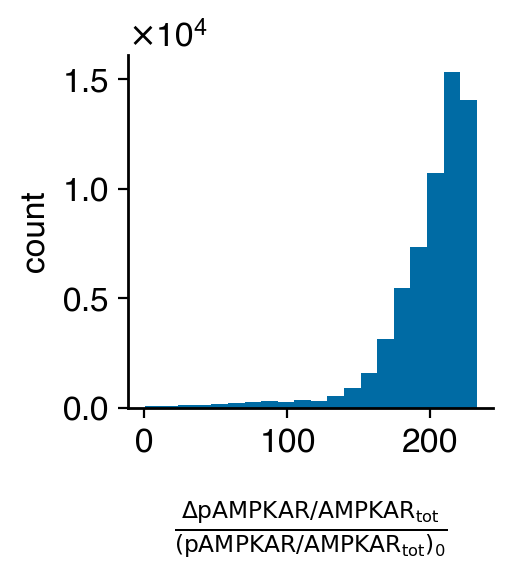

In [14]:
# histogram of output quantities of interest
fig, ax = plt.subplots(1,1, figsize=(8/3,3))
ax.hist(sobol_sols_corr[:,0], bins=20)
ax.set_xlabel(r'$\frac{\Delta pAMPKAR/AMPKAR_{tot}}{(pAMPKAR/AMPKAR_{tot})_0}$', labelpad=15)
ax.set_ylabel('count')
# ax[1].hist(sobol_sols_corr[:,1], bins=20)
# ax[1].set_xlabel('basal steady state \n pAMPKAR/AMPKAR', labelpad=15)
# ax[2].hist(sobol_sols_corr[:,2], bins=20)
# ax[2].set_xlabel('stress steady state \n pAMPKAR/AMPKAR', labelpad=15)
# fig.suptitle('Mass Action Double-binding QoIs')
fig.savefig('./MA_double_mech_tmp/qoi_hists.pdf')
plt.show()

### Compute relevant sensitivity indices

We will compute sobol indices and the HDMR indices

In [77]:
# compute Sobol and Morris indices
Si_sobol_delta = sobol_analyze.analyze(problem, sobol_sols_corr[:,0], calc_second_order=True)

# # compute HDMR indices
Si_hdmr_delta = hdmr_analyze(problem, param_vals_sobol_corr, sobol_sols_corr[:,0])

In [78]:
# sort sobol indices by ST
dtype = [('name', 'U10'), ('S1', float), ('S1_conf', float), ('ST', float), ('ST_conf', float)]

Si_sobol_delta_sorted = np.array([(name, S1, S1_conf, ST, ST_conf) for 
                               name, S1, S1_conf, ST, ST_conf in zip(param_names_MA, Si_sobol_delta['S1'], Si_sobol_delta['S1_conf'], Si_sobol_delta['ST'], Si_sobol_delta['ST_conf'])], dtype=dtype)
Si_sobol_delta_sorted = np.sort(Si_sobol_delta_sorted, order='ST')[::-1]

# hdmr


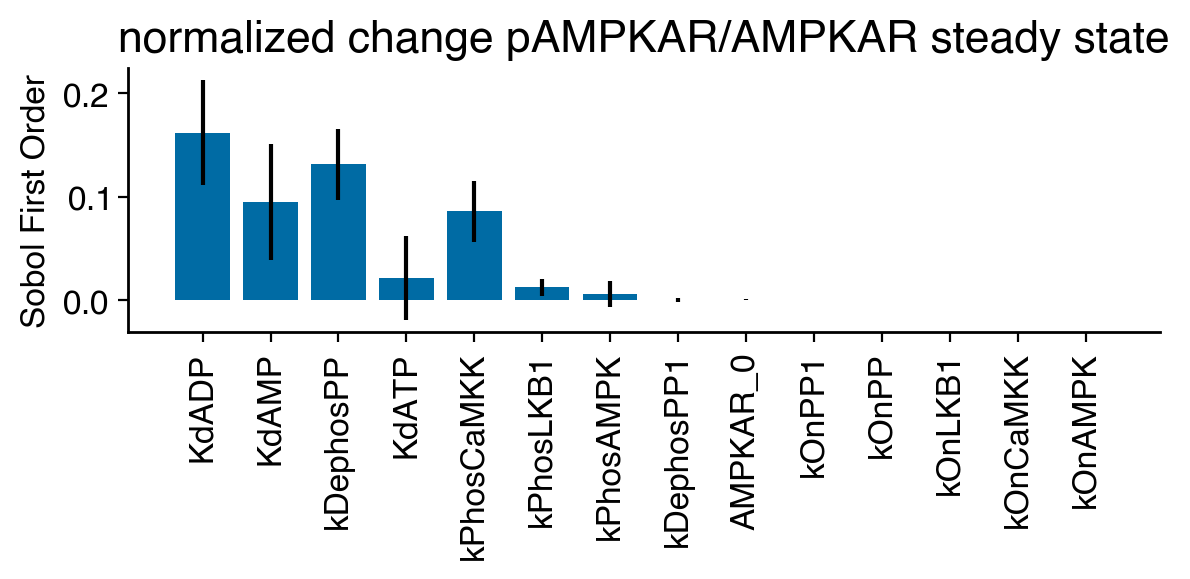

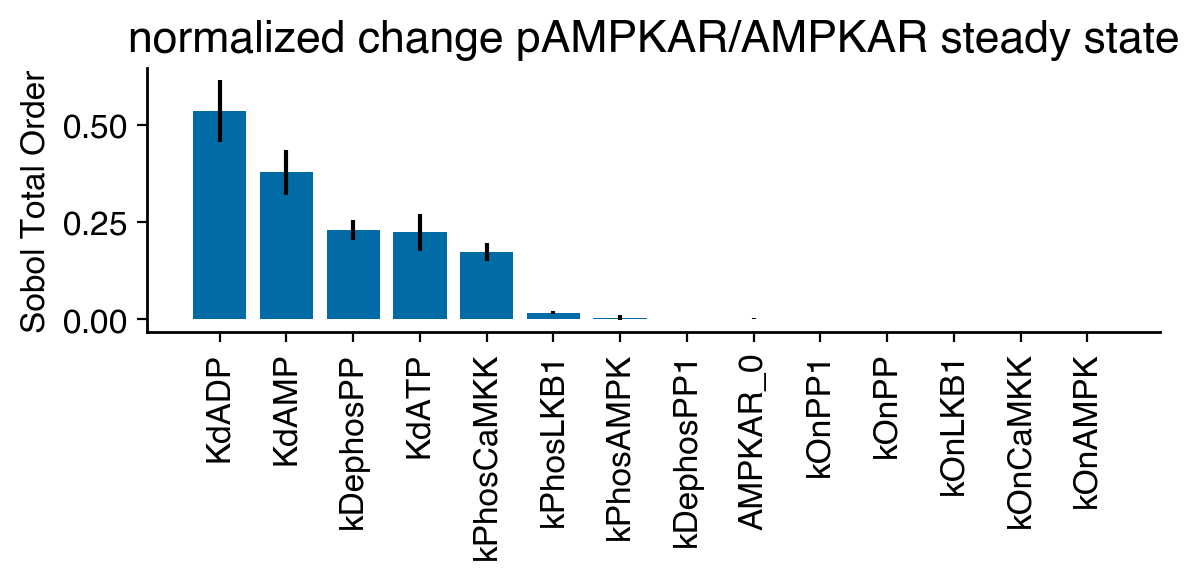

In [79]:
fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,14), Si_sobol_delta_sorted['S1'],
        yerr=Si_sobol_delta_sorted['S1_conf'],
        log=False)
plt.xticks(np.arange(0,14), Si_sobol_delta_sorted['name'], rotation='vertical')
plt.ylabel('Sobol First Order')
plt.title('normalized change pAMPKAR/AMPKAR steady state', weight='normal')
fig.savefig('./MA_double_mech_tmp/S1_change.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,14), Si_sobol_delta_sorted['ST'],
        yerr=Si_sobol_delta_sorted['ST_conf'],
        log=False)
plt.xticks(np.arange(0,14), Si_sobol_delta_sorted['name'], rotation='vertical')
plt.ylabel('Sobol Total Order')
plt.title('normalized change pAMPKAR/AMPKAR steady state', weight='normal')
fig.savefig('./MA_double_mech_tmp/ST_change.pdf')
plt.show()

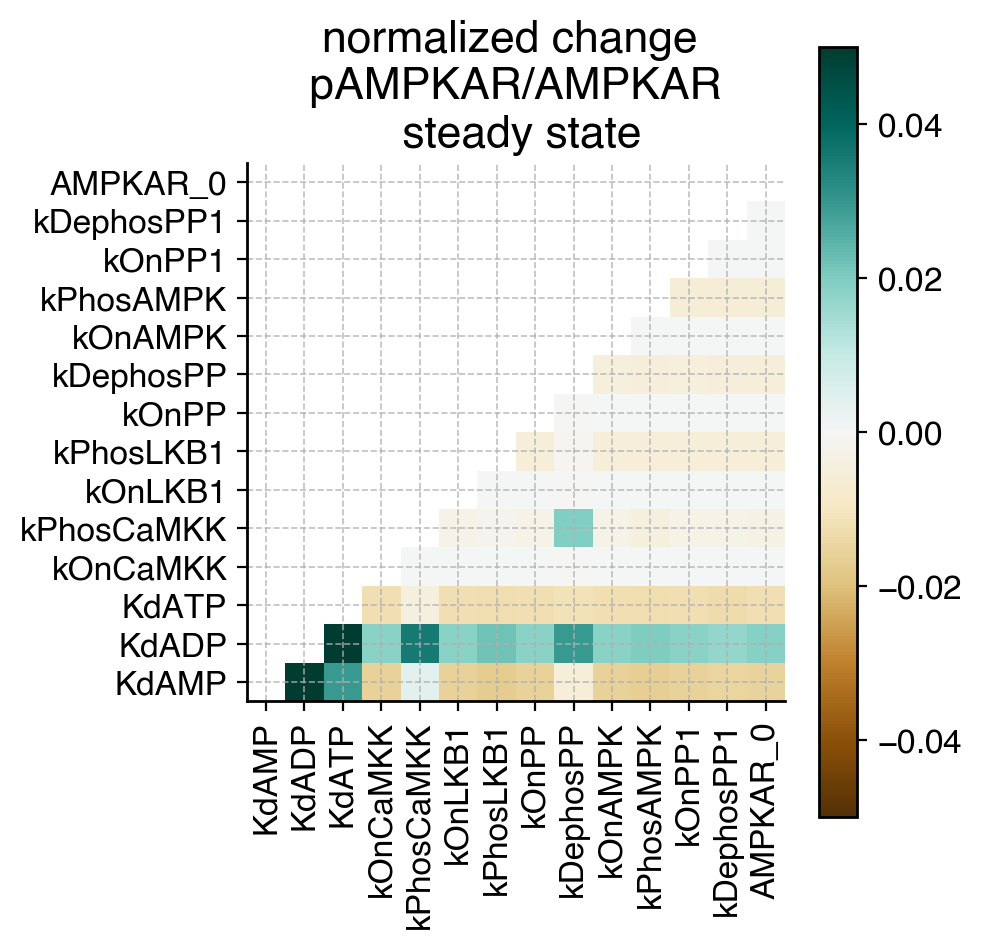

In [80]:
# plot second order
fig, ax = plt.subplots(figsize=(5,5))
cf = ax.pcolormesh(Si_sobol_delta['S2'], vmin=-0.05, vmax=0.05, cmap='BrBG')
fig.colorbar(cf, ax=ax)
ax.set_xticks(np.arange(0,len(param_names_MA))+0.5, labels=param_names_MA, rotation='vertical')
ax.set_yticks(np.arange(0,len(param_names_MA))+0.5, labels=param_names_MA)
ax.grid(True)
ax.set_aspect('equal')
ax.set_title('normalized change \n pAMPKAR/AMPKAR \n steady state', weight='normal')
fig.savefig('./MA_double_mech_tmp/S2_change.pdf')

#### Now for HDMR indices

In [81]:
dtype = [('name', 'U10'), ('Sa', float), ('Sa_conf', float), ('Sb', float), ('Sb_conf', float), ('S', float), ('S_conf', float), ('ST', float), ('ST_conf', float)]

Si_hdmr_delta_sorted = np.array([(name, Sa, Sa_conf, Sb, Sb_conf, S, S_conf, ST, ST_conf) for 
                               name, Sa, Sa_conf, Sb, Sb_conf, S, S_conf, ST, ST_conf in zip(param_names_MA, 
                                                                                             Si_hdmr_delta['Sa'], Si_hdmr_delta['Sa_conf'], 
                                                                                             Si_hdmr_delta['Sb'], Si_hdmr_delta['Sb_conf'],
                                                                                             Si_hdmr_delta['S'], Si_hdmr_delta['S_conf'],
                                                                                             Si_hdmr_delta['ST'], Si_hdmr_delta['ST_conf'])], dtype=dtype)
Si_hdmr_delta_sorted = np.sort(Si_hdmr_delta_sorted, order='S')[::-1]

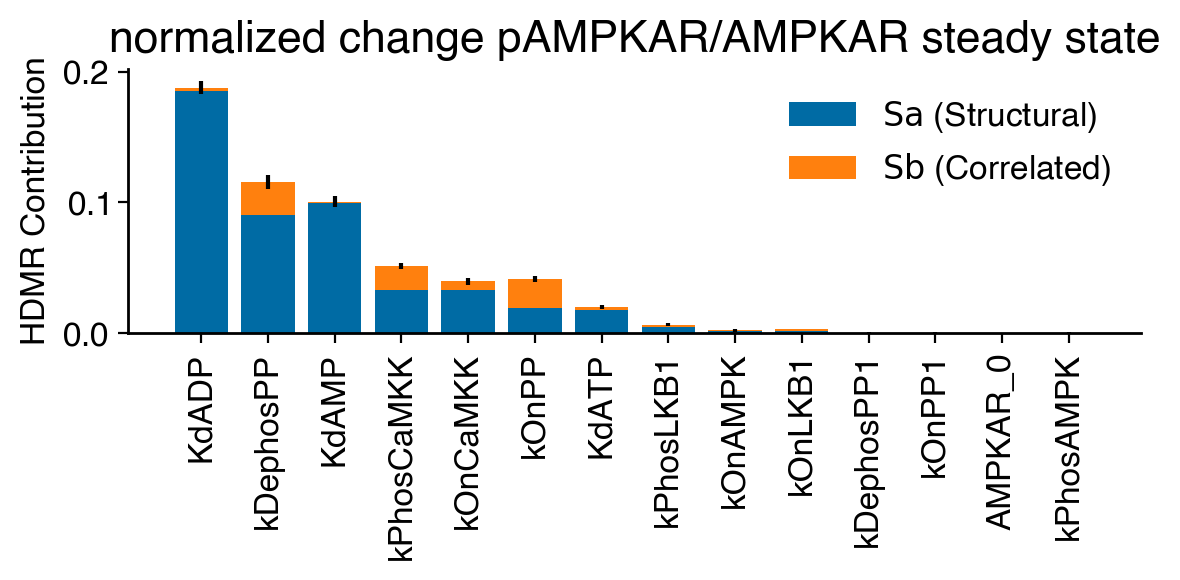

In [82]:
# now visualize the HDMR indices
fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,len(Si_hdmr_delta_sorted['Sa'][0:14])), 
       Si_hdmr_delta_sorted['Sa'][0:14],
       bottom=np.zeros(len(Si_hdmr_delta_sorted['Sa'][0:14])), 
       label=r'$Sa$ (Structural)')
ax.bar(np.arange(0,len(Si_hdmr_delta_sorted['Sb'][0:14])), 
       Si_hdmr_delta_sorted['Sb'][0:14],
       bottom=Si_hdmr_delta_sorted['Sa'][0:14], 
       label=r'$Sb$ (Correlated)',
       yerr=Si_hdmr_delta_sorted['S_conf'])
plt.xticks(np.arange(0, len(Si_hdmr_delta_sorted['name'][0:14])), Si_hdmr_delta_sorted['name'][0:14], rotation='vertical')
plt.ylabel('HDMR Contribution')
# ax.set_yscale('log')
plt.legend()
plt.title('normalized change pAMPKAR/AMPKAR steady state', weight='normal')
plt.show()
fig.savefig('./MA_double_mech_tmp/hdmr_change.pdf')

In [37]:
state_names = ['AMP', 'ADP', 'ATP', 'AMPK', 'pAMPK', 'AMP_AMPK', 'ADP_AMPK', 'ATP_AMPK', 'AMP_pAMPK', 'ADP_pAMPK', 'ATP_pAMPK', 'AMP_AMP_AMPK', 'AMP_ADP_AMPK', 'AMP_ATP_AMPK', 'ADP_ADP_AMPK', 'ADP_ATP_AMPK', 'ATP_ATP_AMPK', 'AMP_AMP_pAMPK', 'AMP_ADP_pAMPK', 'AMP_ATP_pAMPK', 'ADP_ADP_pAMPK', 'ADP_ATP_pAMPK', 'ATP_ATP_pAMPK', 'CaMKK', 'CaMKK_AMPK', 'CaMKK_AMP_AMPK', 'CaMKK_ADP_AMPK', 'CaMKK_ATP_AMPK', 'CaMKK_AMP_AMP_AMPK', 'CaMKK_AMP_ADP_AMPK', 'CaMKK_AMP_ATP_AMPK', 'CaMKK_ADP_ADP_AMPK', 'CaMKK_ADP_ATP_AMPK', 'CaMKK_ATP_ATP_AMPK', 'LKB1', 'LKB1_AMP_AMPK', 'LKB1_ADP_AMPK', 'LKB1_AMP_AMP_AMPK', 'LKB1_AMP_ADP_AMPK', 'LKB1_ADP_ADP_AMPK', 'PP', 'PP_pAMPK', 'PP_ATP_pAMPK', 'PP_AMP_ATP_pAMPK', 'PP_ADP_ATP_pAMPK', 'PP_ATP_ATP_pAMPK', 'AMPKAR', 'pAMPKAR', 'AMPKAR_AMP_pAMPK', 'AMPKAR_AMP_AMP_pAMPK', 'AMPKAR_AMP_ADP_pAMPK', 'PP1', 'PP1_pAMPKAR']

# initial conditions
to_set = ['AMP', 'ADP', 'ATP', 'AMPK', 'CaMKK', 'LKB1', 'PP', 'AMPKAR', 'PP1']
idxs = [state_names.index(item) for item in to_set]

# print(idxs)

y0 = np.zeros((53,))
y0[idxs[0]] = 2e-5   # 'AMP' mM
y0[idxs[1]] = 1.3e-1 # 'ADP mM
y0[idxs[2]] = 8.2   # 'ATP mM
y0[idxs[3]] = 0.6   # 'AMPK mM
y0[idxs[4]] = 1.0   # 'CaMKK_AMPK mM
y0[idxs[5]] = 1.0   # 'CaMKK_AMPK mM
y0[idxs[6]] = 1.0   # 'CaMKK_AMPK mM
y0[idxs[7]] = 0.1   # 'AMPKAR mM
y0[idxs[8]] = 1.0   # 'CaMKK_AMPK mM

y0 = np.array(y0)

# function to compute all MA params from sampled params
def compute_MA_params(params):
    return (1.0, # kOnAMP
            params[0], # kOffAMP
            1.0 , # kOnADP
            params[1], # kOffADP
            1.0, # kOnATP
            params[2], # kOffATP
            params[3], # kOnCaMKK
            1.0, # kOffCaMKK
            params[4], # kPhosCaMKK
            params[5], # kOnLKB1
            1.0, # kOffLKB1
            params[6], # kPhosLKB1
            params[7], # kOnPP
            1.0, # kOffPP
            params[8], # kDephosPP
            params[9], # kOnAMPK
            1.0, # kOffAMPK
            params[10], # kPhosAMPK
            params[11], # kOnPP1
            1.0, # kOffPP1
            params[12]) # kDephosPP1

# parameters
# metabolism_params
metab_parms_basal = {'kGly': 1300.0,'kHydro':1.4e-3,'kForAK':40.44,
                     'kRevAK':1.1e-3,'VmaxOxPhos':0.5,'Kadp': 5.8e-2,'n': 2.568,}
metab_parms_stress = {'kGly': 45.0,'kHydro':1.4e-3,'kForAK':40.44,
                      'kRevAK':1.1e-3,'VmaxOxPhos':0.5,'Kadp': 5.8e-2,'n': 2.568,}

## Now test a solve to steady-state function
@jax.jit
def solve_model(params, rhs, y0, t1, times):
    y0 = y0.at[46].set(params[-1])
    params = compute_MA_params(params)
    solver=dfrx.Kvaerno5()
    stepsize_controller = dfrx.PIDController(rtol=1e-10, atol=1e-10)
    t0 = 0.0
    # times = jnp.arange(t0, t1, 0.5)
    dt0 = 1e-8 # initial time step
    saveat=dfrx.SaveAt(ts=times)

    # initial solve
    sol = dfrx.diffeqsolve(
        rhs, 
        solver, 
        t0, t1, dt0, 
        y0, 
        saveat=saveat, 
        stepsize_controller=stepsize_controller,
        args=params)
    
    return sol # returns the final state

################################################
#                   Model RHS                  #
################################################
rhs = model.ampk_MA_double_mech(**metab_parms_basal)
rhs_stress = model.ampk_MA_double_mech(**metab_parms_stress)
rhs = dfrx.ODETerm(rhs)
rhs_stress = dfrx.ODETerm(rhs_stress)

# run once to compile
times = jnp.arange(0.0, 1000.0, 0.5)
sol = solve_model(nominal_vals_MA, rhs_stress, y0, 1000.0, times)
solve_model(nominal_vals_MA, rhs_stress, y0, 1000.0, times)

Solution(
  t0=f64[],
  t1=f64[],
  ts=f64[2000],
  ys=f64[2000,53],
  interpolation=None,
  stats={
    'max_steps':
    i64[],
    'num_accepted_steps':
    i64[],
    'num_rejected_steps':
    i64[],
    'num_steps':
    i64[]
  },
  result=i64[],
  solver_state=None,
  controller_state=None,
  made_jump=None
)

In [32]:
a = jnp.array(nominal_vals_MA)

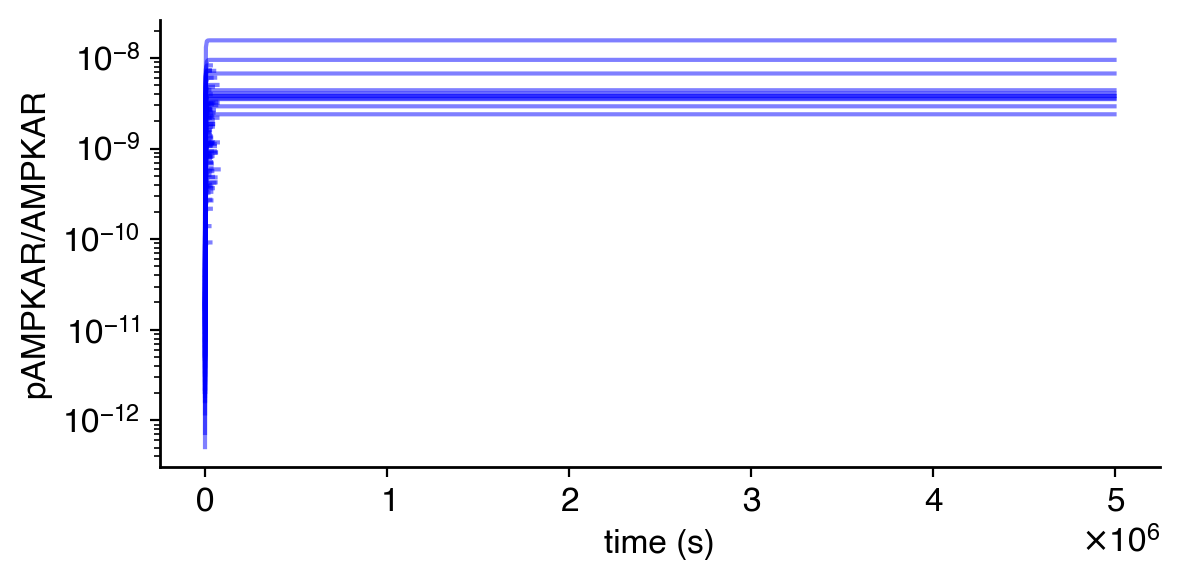

In [33]:
# draw some random samples from the parameter vector
n_samples = 100
idxs = np.random.choice(np.arange(len(param_vals_sobol_corr)), size=(n_samples,), replace=False)
half_maxes = []
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
for i in range(n_samples):
    # get the sample
    sample = param_vals_sobol_corr[idxs[i],:]
    sol = sobol_sols_corr[idxs[i],:]
    # run the model to initial steady-state
    times = jnp.arange(0.0, sol[1], sol[1]/1000)
    sol_1 = solve_model(sample, rhs, y0, sol[1], times)
    # now actually run to get a solution
    # note sol[0] will be the ic and sol[1] will be the time to steady-state
    times = jnp.arange(0.0, sol[2], sol[2]/1000)
    sol_2 = solve_model(sample, rhs_stress, sol_1.ys[-1,:], sol[2], times)
    # plot the solution
    # ax.plot(sol_1.ts, sol_1.ys[:,47]/sol_1.ys[:,46], 'k', label=f'sample {idxs[i]}', alpha=0.5)
    # ax.plot(sol_1.ts[-1]+sol_2.ts, sol_2.ys[:,47]/sol_2.ys[:,46], 'b', label=f'sample {idxs[i]}', alpha=0.5)
    ax.plot(sol_2.ts, sol_2.ys[:,47]/sol_2.ys[:,46], 'b', label=f'sample {idxs[i]}', alpha=0.5)
    traj = sol_2.ys[:,47]/sol_2.ys[:,46]
    half_maxes.append(sol_2.ts[np.argmin(np.abs(traj-(np.max(traj)/2.0)))])
ax.set_yscale('log')
ax.set_xlabel('time (s)')
ax.set_ylabel('pAMPKAR/AMPKAR')
fig.savefig('./MA_double_mech_tmp/stress_responses.pdf', bbox_inches='tight')

In [51]:
param_names_MA

['KdAMP',
 'KdADP',
 'KdATP',
 'kOnCaMKK',
 'kPhosCaMKK',
 'kOnLKB1',
 'kPhosLKB1',
 'kOnPP',
 'kDephosPP',
 'kOnAMPK',
 'kPhosAMPK',
 'kOnPP1',
 'kDephosPP1',
 'AMPKAR_0']

In [41]:
def update_plot(KdAMP, KdADP, KdATP, kOnCaMKK, kPhosCaMKK, kOnLKB1, kPhosLKB1, kOnPP, kDephosPP, kOnAMPK, kPhosAMPK, kOnPP1, kDephosPP1, AMPKAR_0):
    sample = np.array([KdAMP, KdADP, KdATP, kOnCaMKK, kPhosCaMKK, kOnLKB1, kPhosLKB1, kOnPP, kDephosPP, kOnAMPK*100, kPhosAMPK, kOnPP1, kDephosPP1, AMPKAR_0])
    # sol = sobol_sols_corr[idxs[i],:]
    # run the model to initial steady-state
    tmax = 1e6
    times = jnp.arange(0.0, tmax, tmax/1000)
    sol_1 = solve_model(sample, rhs, y0, tmax, times)
    # now actually run to get a solution
    # note sol[0] will be the ic and sol[1] will be the time to steady-state
    times = jnp.arange(0.0, tmax, tmax/1000)
    sol_2 = solve_model(sample, rhs_stress, sol_1.ys[-1,:], tmax, times)
    # plot the solution
    # ax.plot(sol_1.ts, sol_1.ys[:,47]/sol_1.ys[:,46], 'k', label=f'sample {idxs[i]}', alpha=0.5)
    # ax.plot(sol_1.ts[-1]+sol_2.ts, sol_2.ys[:,47]/sol_2.ys[:,46], 'b', label=f'sample {idxs[i]}', alpha=0.5)
    fig, ax = plt.subplots(2, 1, figsize=(6, 4))
    ax[1].plot(sol_2.ts, (sol_2.ys[:,47]/sol_2.ys[:,46])/(sol_2.ys[0,47]/sol_2.ys[0,46]), 'b')
    # ax[1].plot(sol_2.ts, sol_2.ys[:,47]/(AMPKAR_0), 'b')
    ax[1].set_ylabel(r'$pAMPKAR/AMPKAR_{tot}$')
    # ax[1].set_ylim([0.0, 1e-7])
    ax[1].set_xlabel('time (s)')
    ax[1].set_xlim([0.0, tmax])

    ax[0].plot(sol_1.ts, sol_1.ys[:,47]/sol_1.ys[:,46], 'k')
    ax[0].plot(sol_1.ts[-1]+sol_2.ts, sol_2.ys[:,47]/sol_2.ys[:,46], 'b')
    # ax[0].set_ylim([0, 1e-7])
    ax[0].set_ylabel(r'$pAMPKAR/AMPKAR$')
    ax[0].set_xlabel('time (s)')
    ax[0].set_xlim([0.0, 2*tmax])
    plt.show()

In [42]:
# KdAMP_slider = widgets.FloatSlider(min=0.0, max=bounds_MA[0][1], 
#                                       value=nominal_vals_MA[0], description=param_names_MA[0],
#                                       step=1e-8, continous_update=True, readout_format='.3f')
# KdADP_slider = widgets.FloatSlider(min=0.0, max=bounds_MA[1][1], 
#                                       value=nominal_vals_MA[1], description=param_names_MA[1],
#                                       step=1e-8, readout_format='.3f')
# KdATP_slider = widgets.FloatSlider(min=0.0, max=bounds_MA[2][1], 
#                                       value=nominal_vals_MA[2], description=param_names_MA[2],
#                                       step=1e-8, readout_format='.3f')
# kOnCaMKK_slider = widgets.FloatSlider(min=0.0, max=bounds_MA[3][1], 
#                                       value=nominal_vals_MA[3], description=param_names_MA[3])
# kPhosCaMKK_slider = widgets.FloatSlider(min=bounds_MA[4][0], max=bounds_MA[4][1], 
#                                       value=nominal_vals_MA[4], description=param_names_MA[4])
# kOnLKB1_slider = widgets.FloatSlider(min=0.0, max=bounds_MA[5][1], 
#                                       value=nominal_vals_MA[5], description=param_names_MA[5])
# kPhosLKB1_slider = widgets.FloatSlider(min=bounds_MA[6][0], max=bounds_MA[6][1], 
#                                       value=nominal_vals_MA[6], description=param_names_MA[6])
# kOnPP_slider = widgets.FloatSlider(min=0.0, max=bounds_MA[7][1], 
#                                       value=nominal_vals_MA[7], description=param_names_MA[7])
# kDephosPP_slider = widgets.FloatSlider(min=bounds_MA[8][0], max=bounds_MA[8][1], 
#                                       value=nominal_vals_MA[8], description=param_names_MA[8])
# kOnAMPK_slider = widgets.FloatSlider(min=0.0, max=bounds_MA[9][1], 
#                                       value=nominal_vals_MA[9], description=param_names_MA[9])
# kPhosAMPK_slider = widgets.FloatSlider(min=bounds_MA[10][0], max=bounds_MA[10][1], 
#                                       value=nominal_vals_MA[10], description=param_names_MA[10])
# kOnPP1_slider = widgets.FloatSlider(min=0.0, max=bounds_MA[11][1], 
#                                       value=nominal_vals_MA[11], description=param_names_MA[11], step=1e-8, readout_format='.4f')
# kDephosPP1_slider = widgets.FloatSlider(min=bounds_MA[12][0], max=bounds_MA[12][1], 
#                                       value=nominal_vals_MA[12], description=param_names_MA[12], step=1e-8, readout_format='.4f')
# AMPKAR_0_slider = widgets.FloatSlider(min=0.0, max=bounds_MA[13][1], 
#                                       value=nominal_vals_MA[13], description=param_names_MA[13],
#                                       step=1e-8, continous_update=True, readout_format='.3f')
KdAMP_slider = widgets.FloatSlider(min=0.0, max=bounds_MA[0][1], 
                                      value=nominal_vals_MA[0], 
                                      description=param_names_MA[0],
                                      step=1e-8, continous_update=True, 
                                      readout_format='.8f')
KdADP_slider = widgets.FloatSlider(min=0.0, max=bounds_MA[1][1], 
                                      value=nominal_vals_MA[1], 
                                      description=param_names_MA[1],
                                      step=1e-8, continous_update=True,
                                      readout_format='.8f')
KdATP_slider = widgets.FloatSlider(min=0.0, max=bounds_MA[2][1], 
                                      value=nominal_vals_MA[2], 
                                      description=param_names_MA[2],
                                      step=1e-8, continous_update=True,
                                      readout_format='.4f')
kOnCaMKK_slider = widgets.FloatSlider(min=0.0, max=135.7, #bounds_MA[3][1], 
                                      value=nominal_vals_MA[3], 
                                      description=param_names_MA[3],
                                      step=1e-8, continous_update=True,
                                      readout_format='.4f')
kPhosCaMKK_slider = widgets.FloatSlider(min=1e-8, max=1000, 
                                      value=nominal_vals_MA[4], 
                                      description=param_names_MA[4],
                                      step=1e-8, continous_update=True,
                                      readout_format='.4f')
kOnLKB1_slider = widgets.FloatSlider(min=0.0, max=100*bounds_MA[5][1], 
                                      value=nominal_vals_MA[5], 
                                      description=param_names_MA[5],
                                      step=1e-8, continous_update=True,
                                      readout_format='.4f')
kPhosLKB1_slider = widgets.FloatSlider(min=bounds_MA[6][0], max=1000*bounds_MA[6][1], 
                                      value=nominal_vals_MA[6], 
                                      description=param_names_MA[6],
                                      step=1e-8, continous_update=True,
                                      readout_format='.4f')
kOnPP_slider = widgets.FloatSlider(min=0.0, max=bounds_MA[7][1], 
                                      value=nominal_vals_MA[7], 
                                      description=param_names_MA[7],
                                      step=1e-8, continous_update=True,
                                      readout_format='.4f')
kDephosPP_slider = widgets.FloatSlider(min=bounds_MA[8][0], max=bounds_MA[8][1], 
                                      value=nominal_vals_MA[8], 
                                      description=param_names_MA[8],
                                      step=1e-8, continous_update=True,
                                      readout_format='.4f')
kOnAMPK_slider = widgets.FloatSlider(min=0.0, max=bounds_MA[9][1], 
                                      value=nominal_vals_MA[9], 
                                      description=param_names_MA[9],
                                      step=1e-8, continous_update=True,
                                      readout_format='.4f')
kPhosAMPK_slider = widgets.FloatSlider(min=bounds_MA[10][0], max=bounds_MA[10][1], 
                                      value=nominal_vals_MA[10], 
                                      description=param_names_MA[10],
                                      step=1e-8, continous_update=True,
                                      readout_format='.4f')
kOnPP1_slider = widgets.FloatSlider(min=bounds_MA[11][0], max=bounds_MA[11][1], 
                                      value=nominal_vals_MA[11], 
                                      description=param_names_MA[11],
                                      step=1e-8, continous_update=True,
                                      readout_format='.4f')
kDephosPP1_slider = widgets.FloatSlider(min=bounds_MA[12][0], max=bounds_MA[12][1], 
                                      value=nominal_vals_MA[12], 
                                      description=param_names_MA[12],
                                      step=1e-8, continous_update=True,
                                      readout_format='.4f')
AMPKAR_0_slider = widgets.FloatSlider(min=0.0, max=bounds_MA[13][1], 
                                      value=nominal_vals_MA[13], 
                                      description=param_names_MA[13],
                                      step=1e-8, continous_update=True, 
                                      readout_format='.4f')

widget = widgets.interactive(update_plot, KdAMP=KdAMP_slider, KdADP=KdADP_slider, 
                             KdATP=KdATP_slider, kOnCaMKK=kOnCaMKK_slider, kPhosCaMKK=kPhosCaMKK_slider,
                             kOnLKB1=kOnLKB1_slider, kPhosLKB1=kPhosLKB1_slider, 
                             kOnPP=kOnPP_slider, kDephosPP=kDephosPP_slider,
                             kOnAMPK=kOnAMPK_slider, kPhosAMPK=kPhosAMPK_slider,
                             kOnPP1=kOnPP1_slider, kDephosPP1=kDephosPP1_slider,
                 
                             AMPKAR_0=AMPKAR_0_slider)
display(widget)


interactive(children=(FloatSlider(value=0.0025, description='KdAMP', max=0.00475, readout_format='.8f', step=1…

In [65]:
MA_nominals = pd.read_csv('nominal_params_MA_tmp.csv')
MA_bounds = pd.read_csv('param_bounds_MA_tmp.csv')
MM_nominals = pd.read_csv('nominal_params_MM_tmp.csv')
nominal_vals_MA = MA_nominals['value'].to_list()
param_names_MA = MA_nominals['parameter'].to_list()
bounds_MA = [MA_bounds['lower'].to_list(), MA_bounds['upper'].to_list()]
bounds_MA = [[lb, ub] for lb, ub in zip(bounds_MA[0], bounds_MA[1])]
bound_vals_MA = [[b[0]*nom, b[1]*nom] for nom, b in zip(nominal_vals_MA, bounds_MA)]

nominal_vals_MM = MM_nominals['value'].to_list()
param_names_MM = MM_nominals['parameter'].to_list()

print(nominal_vals_MM)

[0.0025, 0.0015, 0.018, 0.5, 0.0166, 0.5, 2.021, 0.11, 0.067, 6.33, 0.00467, 0.11, 0.067, 0.001]


In [66]:
def mass_action_to_michaelis_menten(k_rev, k_for, k_cat, Et):
	"""function to convert from mass action to michaelis menten parameters
	Returns:
		- Vmax = k_cat * Et
		- Km = (k_rev+k_cat)/k_for
	"""
	return (k_rev+k_cat)/k_for

In [71]:
Km = lambda k_for, k_cat: mass_action_to_michaelis_menten(1.0, k_for, k_cat, 1.0)
kOn = bound_vals_MA[3]
kCat = bound_vals_MA[4]
KmNom = nominal_vals_MM[4]
Km_max = Km(kOn[0], kCat[1])
Km_min = Km(kOn[1], kCat[0])
print('Km min is:', Km_min, 'which is', (Km_min/KmNom), 'times the nominal')
print('Km max is:', Km_max, 'which is', (Km_max/KmNom), 'times the nominal')

Km min is: 9.163911487905453e-05 which is 0.005520428607171959 times the nominal
Km max is: 16.812956095759162 which is 1012.8286804674194 times the nominal


In [8]:
KmNom

0.11